<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 11 </b></center>
<center><b><h5>K-means, K-Medoids</b></center>
<pre>    

# Step 1: Import Libraries

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Step 2: Load the Dataset
Load Given dataset -  StudentsPerformance.csv

In [3]:
df = pd.read_csv('StudentsPerformance.csv')

In [4]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# Step 3: Data Overview
In this step, we examine the dataset structure, summary statistics, and check for missing values.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [6]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [7]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

# Step 4: Display PairPlot

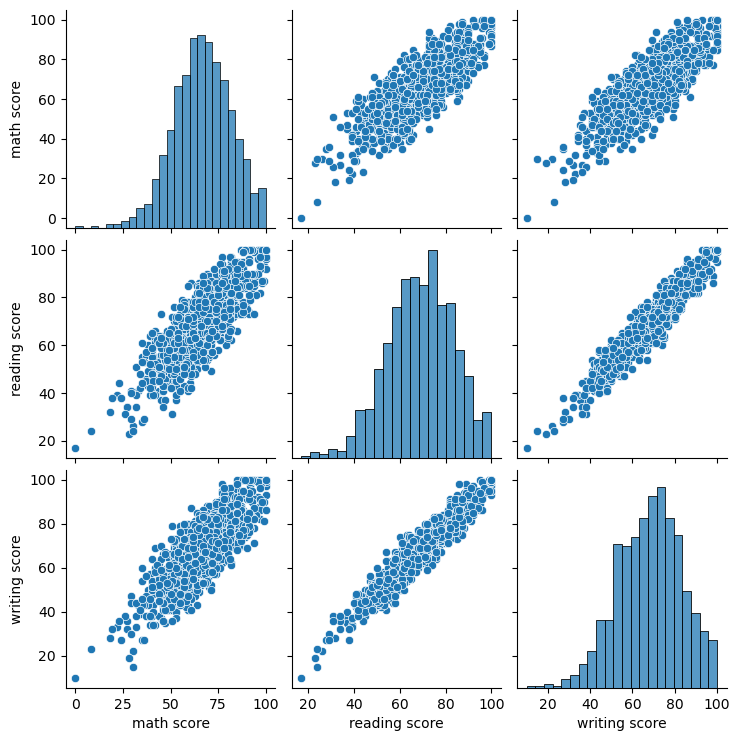

In [8]:
sns.pairplot(df)

# Step 5: Correlation heatmap

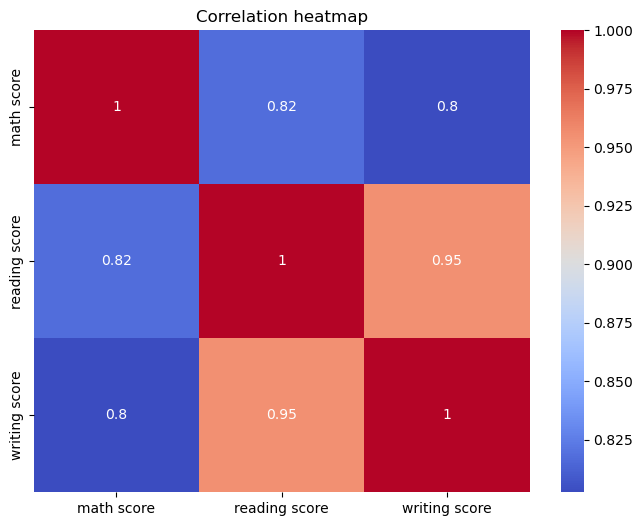

In [14]:
#---step - 6,7
plt.figure(figsize=(8,6))
sns.heatmap(
        numeric_df.corr(),
        annot=True,
        cmap='coolwarm'
)
plt.title('Correlation heatmap')
plt.show()

# Step 6: Distribution of numerical features

In [11]:
numeric_df = df[['math score',
                 'reading score',
                'writing score']]

# Step 7: Apply StandardScaler

In [12]:
X = numeric_df

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.39002351  0.19399858  0.39149181]
 [ 0.19207553  1.42747598  1.31326868]
 [ 1.57771141  1.77010859  1.64247471]
 [-1.25954302 -0.83389925 -1.58374436]
 [ 0.65395415  0.60515772  0.45733301]]


# Step 8: Elbow method to find optimal k

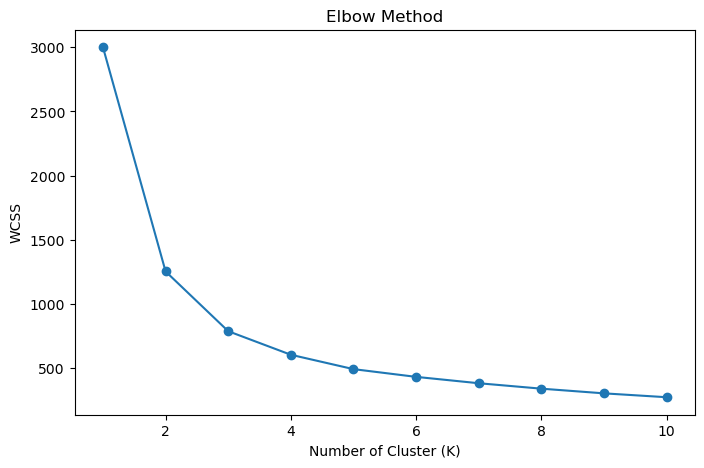

In [15]:
wcss = []
for i in range(1,11):
    kmeans = KMeans(n_clusters = i,
                    random_state=42,
                    n_init=10
                   )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.xlabel('Number of Cluster (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Step 9:Based on the elbow plot, choose an appropriate k value (e.g., k=3)

In [16]:
kmeans = KMeans(n_clusters = 3,
                 random_state=42,
                 n_init=10
                   )
clusters = kmeans.fit_predict(X_scaled)
df['Cluster'] = clusters
df[['math score',
    'reading score',
    'writing score',
    'Cluster']].head()

,math score,reading score,writing score,Cluster
0,72,72,74,0
1,69,90,88,2
2,90,95,93,2
3,47,57,44,1
4,76,78,75,2


# Step 10: Print Cluster Center

In [17]:
centers = scaler.inverse_transform(
    kmeans.cluster_centers_
)

cluster_centers = pd.DataFrame(
    centers,
    columns=['math score',
             'reading score',
             'writing score']
)

print(cluster_centers)

   math score  reading score  writing score
0   65.338600      68.458239      67.821670
1   48.096386      50.670683      48.485944
2   81.714286      85.146104      84.207792


# Step 11: Plot Cluster

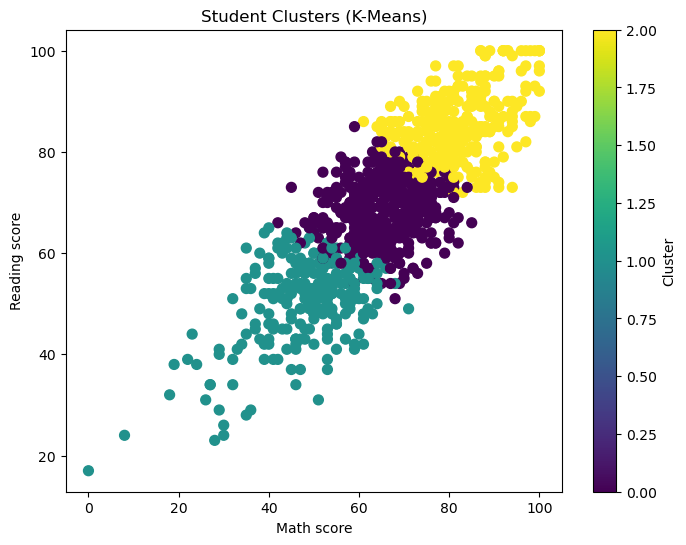

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(
    df['math score'],
    df['reading score'],
    c=df['Cluster'],
    cmap='viridis',
    s=50
)
plt.xlabel('Math score')
plt.ylabel('Reading score')
plt.title('Student Clusters (K-Means)')
plt.colorbar(label='Cluster')
plt.show()

# Step 12:Analyze clusters 

In [19]:
cluster_analysis = df.groupby('Cluster')[[
    'math score',
    'reading score',
    'writing score'
]].mean()

print(cluster_analysis)

         math score  reading score  writing score
Cluster                                          
0         65.338600      68.458239      67.821670
1         48.096386      50.670683      48.485944
2         81.714286      85.146104      84.207792


# Step 13: Perform K-Medoids

In [19]:
from sklearn_extra.cluster import KMedoids

kmedoids = KMedoids(
    n_clusters=3,
    random_state=42
)

kmedoid_labels = kmedoids.fit_predict(X_scaled)

df['KMedoids_Cluster'] = kmedoid_labels

print(df[['Cluster','KMedoids_Cluster']].head())

ModuleNotFoundError: No module named 'sklearn_extra'

In [ ]:
----//!pip install scikit-learn-extra  ----error---

In [20]:
!python --version

Python 3.13.5


# Step:14 Comparison of K-means and K-medoids Clusters

In [21]:
print(df[['Cluster','Kmedoids_labels']]).head()

KeyError: "['Kmedoids_labels'] not in index"

# Step: 15 | USE KMEAN++


In [24]:
kmeans_pp = KMeans(n_clusters = 3,
                   init='k-means++',
                   random_state=42,
                   n_init=10
                   )
labels_pp = kmeans_pp.fit_predict(X_scaled)
df['KMeansPP_Cluster'] = labels_pp
print(df[['KMeansPP_Cluster']].head())

   KMeansPP_Cluster
0                 0
1                 2
2                 2
3                 1
4                 2
